# **Customer Churn Prediction**

### Data Science and Python Capstone Project

**Problem Type:** Binary Classification  
**Dataset:** Telco Customer Churn Dataset  
**Goal:** Predict whether a telecom customer is likely to churn (Yes/No).

---

### ***Project Overview***

Customer churn is an important business problem for telecom companies.
When customers leave a company, it can result in revenue loss and increased
customer acquisition costs.

In this project, we analyze customer information such as tenure,
monthly charges, services, contract type, payment method, and other
customer attributes to understand churn patterns.

We then build and compare two machine learning models:

- Logistic Regression
- Decision Tree Classifier

Finally, we evaluate the models using accuracy, precision, recall,
F1-score, and confusion matrix to identify the better-performing model
and generate useful business insights.

## ***Project Objectives***

The main objectives of this project are:

• Load and understand the Telco Customer Churn dataset.

• Explore customer characteristics and churn patterns.

• Identify and handle missing or incorrect data.

• Convert categorical variables into numerical form.

• Scale important numerical features.

• Split the dataset into training and testing sets.

• Build a Logistic Regression model.

• Build a Decision Tree Classifier.

• Compare both models using evaluation metrics.

• Identify important business insights that can help reduce customer churn.

In [4]:
# ------------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Set visualization style
sns.set_style("whitegrid")

# Display plots inside the notebook
%matplotlib inline

### **Section 1 — Data Loading and Exploratory Data Analysis (EDA)**

In this section, we load the dataset and understand its structure.
We examine the number of rows and columns, data types, statistical
summary, missing values, and important customer churn patterns.

In [5]:
# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

# Load the Telco Customer Churn dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("telco_churn.csv")

# Display dataset dimensions
print("Shape of dataset:", df.shape)

# Display first five records
df.head()

Saving telco_churn.csv to telco_churn (3).csv
Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# ------------------------------------------------------------
# UNDERSTAND THE DATA
# ------------------------------------------------------------

# Display column names, data types, and non-null values
df.info()

print()

# Generate descriptive statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### *Observation*

The dataset contains 7,043 customer records and 21 columns.

The dataset includes customer demographic information, subscribed
services, contract details, monthly charges, total charges, and churn
status.

The target variable is `Churn`.

In [7]:
# ------------------------------------------------------------
# CHECK FOR MISSING VALUES
# ------------------------------------------------------------

# Count missing values in each column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
# ------------------------------------------------------------
# CHECK TOTALCHARGES DATA TYPE
# ------------------------------------------------------------

# Check the type of values present in TotalCharges
print(df["TotalCharges"].apply(type).value_counts())

TotalCharges
<class 'str'>    7043
Name: count, dtype: int64


In [9]:
# ------------------------------------------------------------
# CLEAN TOTALCHARGES
# ------------------------------------------------------------

# Convert TotalCharges into numeric values.
# Invalid or blank values will become NaN.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values after conversion
print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

Missing TotalCharges values: 11


In [ ]:
# ------------------------------------------------------------
# HANDLE MISSING TOTALCHARGES
# ------------------------------------------------------------

# Fill missing TotalCharges values by using zero values.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify that missing values have been handled
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
# ------------------------------------------------------------
# CALCULATE CHURN RATE
# ------------------------------------------------------------

# value_counts() gives the number of customers in each churn category.
# normalize=True converts these counts into proportions.
churn_rate = df["Churn"].value_counts(normalize=True) * 100

print("Customer Churn Rate:")
print(churn_rate)

Customer Churn Rate:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


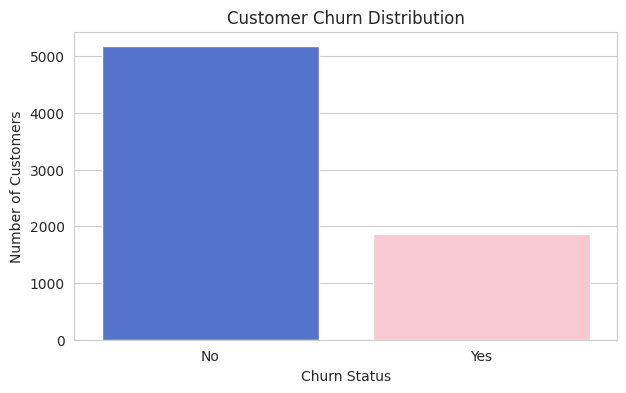

In [ ]:
# ------------------------------------------------------------
# VISUALIZE CHURN DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    legend=False,
    palette= ["royalblue","pink"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### *Finding*

Approximately 26.5% of customers have churned, while around 73.5%
have remained with the company.

This shows that churn is a significant business problem that should
be investigated further.

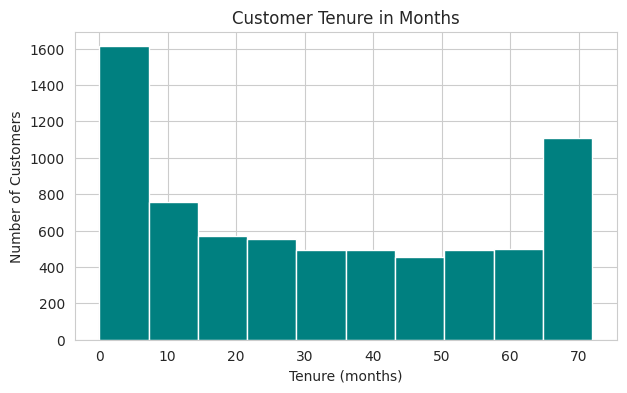

In [ ]:
# ------------------------------------------------------------
# ANALYZE CUSTOMER TENURE
# ------------------------------------------------------------

# A histogram shows how customer tenure is distributed.
plt.figure(figsize=(7, 4))

plt.hist(
    df["tenure"],
    bins=10, color="teal"
)

plt.title("Customer Tenure in Months")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of Customers")

plt.show()

### *Finding*

The tenure distribution shows that the dataset contains both
new and long-term customers.

Customers with very short tenure form a noticeable group, which
is useful because early-stage customers may behave differently
from long-term customers.

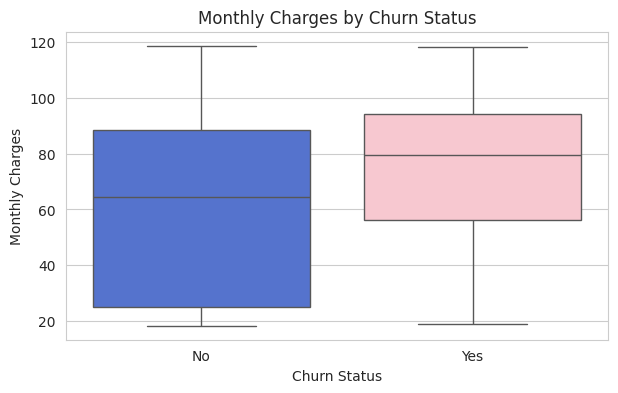

In [ ]:
# ------------------------------------------------------------
# MONTHLY CHARGES VS CHURN
# ------------------------------------------------------------

# Compare monthly charges between customers who churned
# and customers who stayed.

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    legend=False,
    palette= ["royalblue","pink"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

### *Finding*

The boxplot indicates that customers who churned generally have
higher monthly charges compared with many customers who stayed.

However, this relationship represents correlation and does not
prove that higher monthly charges directly cause churn.

## ***Correlation and Causation***

### ***Correlation***

Correlation describes the relationship between two variables.

For example, in this project we can examine relationships between:

- Tenure and TotalCharges
- MonthlyCharges and TotalCharges
- MonthlyCharges and Churn

A relationship between two variables does not necessarily mean
that one variable causes the other.

### ***Causation***

Causation means that a change in one variable directly causes
a change in another variable.

For example, if customers with higher MonthlyCharges show a higher
churn rate, we cannot automatically conclude that higher charges
cause customers to leave.

Other factors may also influence churn, such as:

- Contract type
- Internet service
- Payment method
- Online security
- Technical support
- Customer tenure

Therefore, correlation does not necessarily mean causation.

Further statistical analysis or controlled experiments would be
required to establish a causal relationship.

# **Section 2 — Data Cleaning and Feature Engineering**

In this section, we prepare the dataset for machine learning.

The main steps are:

1. Remove the customer ID because it does not provide useful predictive information.
2. Convert the target variable into numerical form.
3. Encode categorical variables.
4. Scale numerical variables.
5. Separate features and target.

In [ ]:
# ------------------------------------------------------------
# REMOVE CUSTOMER ID
# ------------------------------------------------------------

# CustomerID is an identifier and does not provide useful
# information for predicting customer churn.
df = df.drop(columns=["customerID"])

print("Shape after dropping customerID:", df.shape)

Shape after dropping customerID: (7043, 20)


In [ ]:
# ------------------------------------------------------------
# ENCODE TARGET VARIABLE
# ------------------------------------------------------------

# Convert Churn from Yes/No into 1/0.
# 1 = Customer churned
# 0 = Customer stayed

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Check target distribution
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# ------------------------------------------------------------
# ENCODE CATEGORICAL VARIABLES
# ------------------------------------------------------------

# Identify categorical columns
categorical_cols = df.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)
print("\n")

# Convert categorical variables into numerical dummy variables.
# drop_first=True avoids unnecessary duplicate information.
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded dataset shape:", df_encoded.shape)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Encoded dataset shape: (7043, 31)


In [ ]:
# ------------------------------------------------------------
# SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

# X contains input features.
# y contains the target variable, Churn.

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 30)
Target shape: (7043,)


In [ ]:
# ------------------------------------------------------------
# TRAIN-TEST SPLIT
# ------------------------------------------------------------


# Split the data into:
# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [ ]:
# ------------------------------------------------------------
# SCALE NUMERICAL FEATURES
# ------------------------------------------------------------

# These numerical features have different ranges,
# so StandardScaler is used to standardize them.

numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

scaler = StandardScaler()

# Fit the scaler only on training data
X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

# Apply the same transformation to test data
X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

print("Numerical features have been scaled successfully.")

Numerical features have been scaled successfully.


# **Section 3 — Machine Learning Model Building**

Two supervised machine learning classification models are used:

1. Logistic Regression
2. Decision Tree Classifier
3. K-Means Clustering

Both models are trained using the same training data and evaluated
on the same test data so that their performance can be compared fairly.

In [ ]:
# ------------------------------------------------------------
# LOGISTIC REGRESSION
# ------------------------------------------------------------

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train, y_train)

# Predict churn on test data
y_pred_lr = logistic_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      lr_accuracy * 100)

Logistic Regression Accuracy: 80.62455642299503


In [ ]:
# ------------------------------------------------------------
# LOGISTIC REGRESSION EVALUATION
# ------------------------------------------------------------

lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", lr_accuracy * 100)
print("Precision:", lr_precision * 100)
print("Recall   :", lr_recall * 100)
print("F1-Score :", lr_f1 * 100)

Logistic Regression Results
--------------------------------
Accuracy : 80.62455642299503
Precision: 65.93059936908517
Recall   : 55.88235294117647
F1-Score : 60.492040520984084


In [ ]:
# ------------------------------------------------------------
# DECISION TREE CLASSIFIER
# ------------------------------------------------------------

# Create the Decision Tree model
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Predict churn on test data
y_pred_dt = decision_tree.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:",
      dt_accuracy * 100)

Decision Tree Accuracy: 79.4180269694819


In [ ]:
# ------------------------------------------------------------
# DECISION TREE EVALUATION
# ------------------------------------------------------------

dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------------------")
print("Accuracy :", dt_accuracy * 100)
print("Precision:", dt_precision * 100)
print("Recall   :", dt_recall * 100)
print("F1-Score :", dt_f1 * 100)

Decision Tree Results
--------------------------------
Accuracy : 79.4180269694819
Precision: 63.125
Recall   : 54.01069518716578
F1-Score : 58.21325648414985


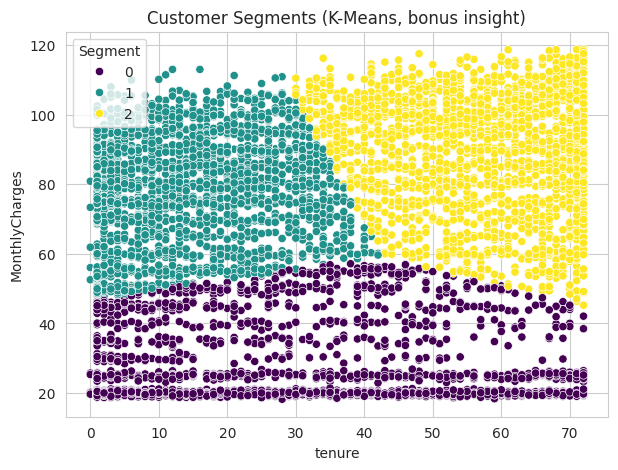

In [ ]:
# ------------------------------------------------------------
# K-MEANS CLUSTERING
# ------------------------------------------------------------

# It's a way to discover natural customer segments based on tenure and monthly charges.
from sklearn.cluster import KMeans

cluster_features = df_encoded[["tenure", "MonthlyCharges"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_encoded["Segment"] = kmeans.fit_predict(cluster_features)

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_encoded, x="tenure", y="MonthlyCharges",
    hue="Segment", palette="viridis"
)
plt.title("Customer Segments (K-Means, bonus insight)")
plt.show()

## **Section 4 — Model Evaluation and Comparison**

Accuracy alone is not sufficient for a churn prediction problem.

We evaluate the models using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

For a churn problem, Recall is particularly important because missing
a customer who is actually going to churn can result in lost revenue.

In [ ]:
# ------------------------------------------------------------
# COMPARE MODEL PERFORMANCE
# ------------------------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall
    ],
    "F1-Score": [
        lr_f1,
        dt_f1
    ]
})

# Display results as percentages
results_display = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,80.62,65.93,55.88,60.49
1,Decision Tree,79.42,63.12,54.01,58.21


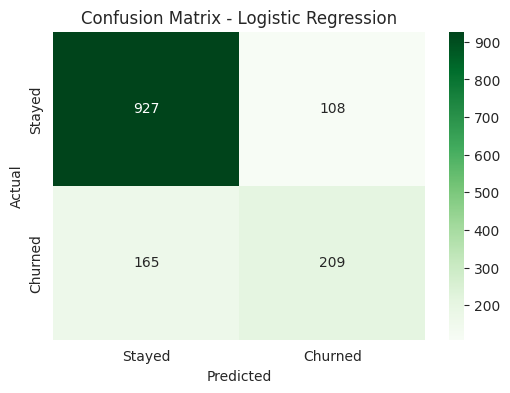

In [ ]:
# ------------------------------------------------------------
# CONFUSION MATRIX — LOGISTIC REGRESSION
# ------------------------------------------------------------

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

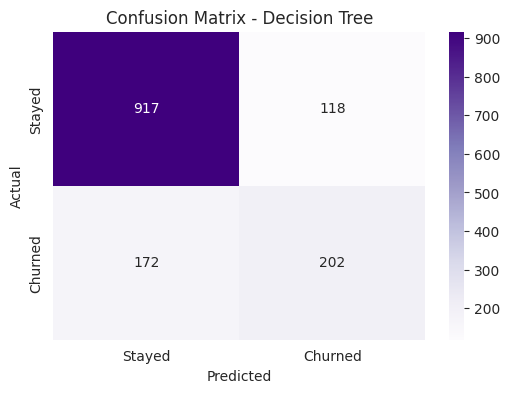

In [ ]:
# ------------------------------------------------------------
# CONFUSION MATRIX — DECISION TREE
# ------------------------------------------------------------

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("Logistic Regression Classification Report")
print("-------------------------------------------")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Stayed", "Churned"]
    )
)

print("\nDecision Tree Classification Report")
print("------------------------------------")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Stayed", "Churned"]
    )
)

Logistic Regression Classification Report
-------------------------------------------
              precision    recall  f1-score   support

      Stayed       0.85      0.90      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Decision Tree Classification Report
------------------------------------
              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1035
     Churned       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



# ***Business Insights***

Based on the exploratory analysis and model evaluation, the following
business insights can be considered:

### 1. Customer Churn is Significant
Around 26.5% of customers in the dataset have churned. This indicates
that customer retention should be an important business priority.

### 2. Monthly Charges and Churn
Customers with higher monthly charges show a tendency toward higher
churn in the exploratory analysis. However, this relationship should
not be interpreted as direct causation.

### 3. Customer Tenure
Customers with shorter tenure represent an important group to monitor.
Early customer engagement and better onboarding may help improve retention.

### 4. Churn Prediction Can Support Retention
A machine learning model can help identify customers who are more likely
to churn. The company can then focus retention efforts on these customers.

### 5. Recall Matters
For churn prediction, missing an actual churner can be costly because
the company may lose that customer without taking preventive action.
Therefore, recall is an important metric alongside precision and F1-score.

# ***Business Recommendations***

Based on the analysis, the telecom company could consider:

- Offering targeted retention plans to customers at high risk of churn.
- Improving onboarding and engagement for new customers.
- Reviewing pricing and service bundles for customers with high monthly charges.
- Providing better technical and online support.
- Using churn prediction models as an early-warning system for the
  customer retention team.

# **Conclusion**

This project analyzed the Telco Customer Churn dataset to understand
the factors associated with customer churn and to build predictive
classification models. The data was cleaned, categorical variables
were encoded, and numerical features were standardized before model
training. Logistic Regression and Decision Tree models were developed
and compared using accuracy, precision, recall, and F1-score. The
better-performing model can be used as an early-warning tool to
identify customers who may be at risk of leaving and support targeted
customer retention strategies.